<a href="https://colab.research.google.com/github/hirenpatel1404/Project_4_Unsupervised_Image_Clustering_and_Visualization/blob/main/Project__4__Handwritten_digit_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Hiren Patel
##Can Unsupervised Learning Discover Groups in Handwritten Digits?

#Part 1 — Explore the Images

In [11]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

In [10]:
# Load the handwritten digit dataset.
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

In [3]:
# Store the images and their actual digit labels.
X = mnist.data
y = mnist.target

In [4]:
# Keep the labels separate from the data used for clustering.
print("Number of images:", X.shape[0])
print("Number of features:", X.shape[1])
print("Data type:", X.dtype)
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Number of images: 70000
Number of features: 784
Data type: int64
Minimum pixel value: 0
Maximum pixel value: 255


In [5]:
# Check the shape of one image before and after reshaping.
print("Flat image shape:", X[0].shape)
print("Reshaped image shape:", X[0].reshape(28, 28).shape)

Flat image shape: (784,)
Reshaped image shape: (28, 28)


### Loading and exploring the data
I loaded the MNIST dataset and checked its size, data type, and pixel-value range. The output shows 70,000 images, each with 784 features. Each image has 28 rows and 28 columns of pixels, so \(28 \times 28 = 784\). Each feature represents the brightness of one pixel.
The original data type is int64, meaning the pixel values are stored as integers. These values range from 0 to 255. In the grayscale display, 0 represents black, 255 represents white, and values between them represent shades of gray.
The flat image shape, (784,), means each image is stored as a single sequence of 784 values. Reshaping it to (28, 28) restores its two-dimensional layout so it can be displayed as a digit.

###2. Display sample images

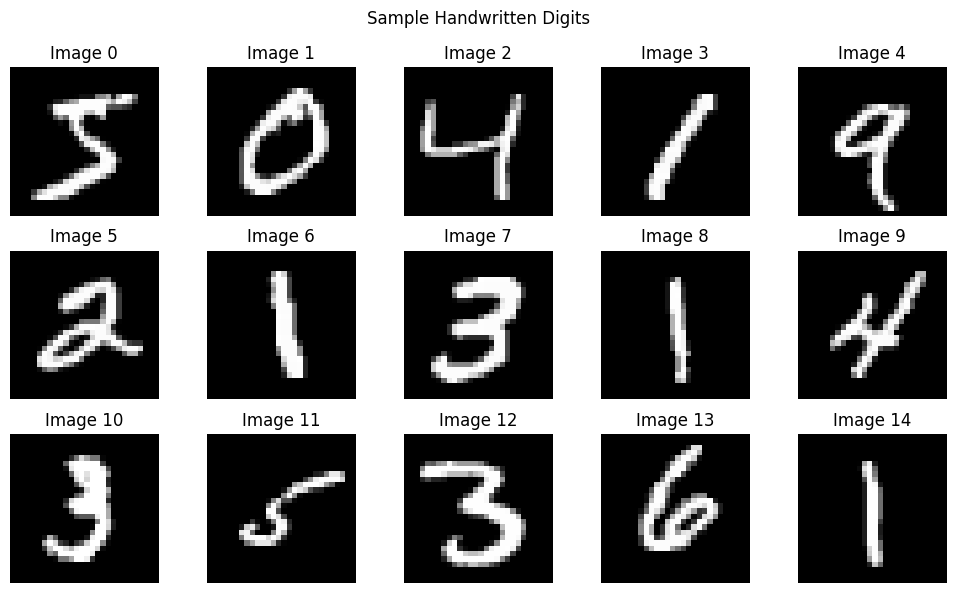

In [7]:
# Show the first 15 images in three rows.
fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for i, ax in enumerate(axes.flat):
    # Turn each row of pixel values into a square image.
    ax.imshow(X[i].reshape(28, 28), cmap="gray")

    # Use the image number to identify each example.
    ax.set_title(f"Image {i}")
    ax.axis("off")

plt.suptitle("Sample Handwritten Digits")
plt.tight_layout()
plt.show()

### Explaining the sample image plot
I displayed 15 handwritten digit images in a grid with three rows and five columns. The bright strokes show the handwritten digits, while the black areas show the background. Titles such as “Image 0” identify the image’s position in the dataset; they are not digit labels.
The plot shows differences in writing style, including stroke thickness, angle, and shape. For example, Images 3 and 8 both appear to show the digit 1, but Image 3 is slanted while Image 8 is more upright. Images 7 and 12 appear to show the digit 3, but their curves and thickness differ. These examples show that the same digit can have different pixel patterns because people write differently.

###3. Normalize the pixel values

In [8]:
# Use the original data so rerunning this cell does not divide twice.
X = mnist.data / 255.0

# Check the pixel range after normalization.
print("Minimum normalized pixel value:", X.min())
print("Maximum normalized pixel value:", X.max())
print("Shape after normalization:", X.shape)

Minimum normalized pixel value: 0.0
Maximum normalized pixel value: 1.0
Shape after normalization: (70000, 784)


### Normalizing the pixel values
I divided the original pixel values by 255. The resulting minimum is 0.0 and the maximum is 1.0, confirming that normalization worked. The shape remains (70000, 784), so no images or features were removed.
Normalization puts pixel values on a smaller, consistent scale while preserving the image patterns. Since every feature is divided by the same number, it rescales distances between images without changing their relative similarity.
Short summary
I loaded and explored the dataset, displayed sample digits, and normalized the pixel values. The results confirm that the dataset contains 70,000 images with 784 pixel features each. The sample plot shows variation in handwriting, and the normalized data is ready for the next part

###1. How many images are in the dataset?
The dataset contains 70,000 images, as shown by the output from X.shape[0].

###2. Why does each image have 784 features?
Each image has 28 rows and 28 columns of pixels. Therefore, \(28 \times 28 = 784\) pixels. When the image is flattened into a single row, each pixel becomes one feature.

###3. What do the pixel values represent?
Pixel values represent brightness. In the grayscale plot, 0 means black, 255 means white, and values between them represent shades of gray. The bright pixels form the handwritten digit against the black background.

###4. Why do images of the same digit look different?
People write with different shapes, angles, sizes, and stroke thicknesses. For example, I observed that Images 3 and 8 both resemble the digit 1, but one is slanted while the other is more upright.

###5. Why do we normalize the pixel values?
I divided the pixel values by 255 to change their range from 0–255 to 0–1. This puts the data on a smaller, consistent numerical scale while preserving the image patterns. Because every pixel feature is scaled equally, normalization rescales distances without changing the relative similarity between images.

#Part 2 — Discover Groups Using K-Means

### Select 10,000 images

In [13]:
# Use a fixed seed so the same images are selected each time.
rng = np.random.RandomState(42)

# Select 10,000 different images from the normalized data.
sample_indices = rng.choice(
    len(X),
    size=10000,
    replace=False
)

X_sample = X[sample_indices]

# Keep the labels only for interpretation later.
# Do not give these labels to K-Means.
y_sample = y[sample_indices]

print("Sample shape:", X_sample.shape)
print("Minimum pixel value:", X_sample.min())
print("Maximum pixel value:", X_sample.max())

Sample shape: (10000, 784)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


### Compare K = 5, 10, and 15

In [14]:
# Try the three cluster counts required by the project.
k_values = [5, 10, 15]
inertia_values = []

In [15]:
# Save each model so we can reuse the selected one later.
models = {}

In [16]:
for k in k_values:
    # Create a model with repeatable starting points.
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Train using only the image pixels.
    model.fit(X_sample)

    # Save the model and its inertia.
    models[k] = model
    inertia_values.append(model.inertia_)

    print(f"K = {k}, Inertia = {model.inertia_:,.2f}")

K = 5, Inertia = 432,527.75
K = 10, Inertia = 390,343.06
K = 15, Inertia = 365,525.23


In [17]:
# Show the results in a table.
elbow_results = pd.DataFrame({
    "K": k_values,
    "Inertia": inertia_values
})

display(elbow_results)

,K,Inertia
0,5,432527.750938
1,10,390343.062808
2,15,365525.232506


### Interpretation
I randomly selected 10,000 images to make clustering more manageable. The sample shape, (10000, 784), shows that each image contains 784 pixel features. The pixel values range from 0.0 to 1.0, confirming that the sample is normalized. I used a fixed random seed so the same sample can be selected again.
I trained K-Means with K = 5, 10, and 15, using only the image pixels without the actual digit labels. The inertia values were 432,527.75, 390,343.06, and 365,525.23, respectively. Inertia measures the total squared distance between images and their assigned cluster centers. A lower value indicates more compact clusters, but does not necessarily mean better separation of digits.

### Create the elbow plot

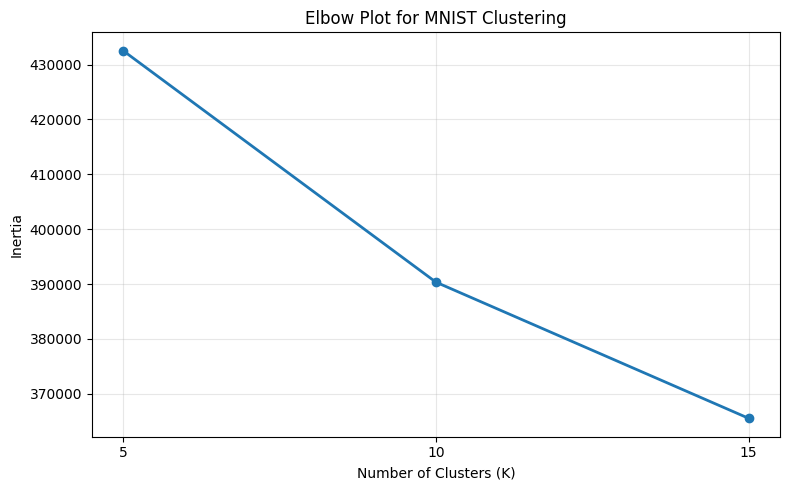

In [18]:
# Plot the inertia for each cluster count.
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia_values,
    marker="o",
    linewidth=2
)

plt.xticks(k_values)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Plot for MNIST Clustering")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The horizontal axis shows the number of clusters, while the vertical axis shows inertia. The downward line shows that inertia decreases as the number of clusters increases.
From K = 5 to K = 10, inertia decreased by approximately 42,185 (9.8%). From K = 10 to K = 15, it decreased by approximately 24,818 (6.4%). The line becomes less steep after K = 10, showing that adding another five clusters produces a smaller improvement.
I selected K = 10 as a reasonable balance between compact clusters and a manageable number of groups. However, three tested values do not establish a definite optimal K, and ten clusters do not guarantee one cluster for each digit.

**Short summary** -

I selected 10,000 normalized images and compared three cluster counts. The elbow plot showed a smaller improvement after K = 10, so I chose 10 clusters for the final model.

### Use the selected model and check cluster sizes

In [19]:
# Choose the cluster count based on the elbow plot.
selected_k = 10

# Reuse the model already trained with 10 clusters.
kmeans = models[selected_k]

# Get the cluster assigned to each sample image.
clusters = kmeans.labels_

# Count the images in each cluster.
cluster_sizes = (
    pd.Series(clusters)
    .value_counts()
    .sort_index()
)

# Create a table with counts and percentages.
cluster_table = pd.DataFrame({
    "Cluster": cluster_sizes.index,
    "Number of images": cluster_sizes.values,
    "Percentage": (
        cluster_sizes.values / len(X_sample) * 100
    ).round(2)
})

display(cluster_table)

# Check that every sample image has a cluster assignment.
print("Total images assigned:", cluster_sizes.sum())

,Cluster,Number of images,Percentage
0,0,519,5.19
1,1,757,7.57
2,2,1487,14.87
3,3,1039,10.39
4,4,1475,14.75
5,5,1331,13.31
6,6,513,5.13
7,7,906,9.06
8,8,1017,10.17
9,9,956,9.56


Total images assigned: 10000


###Interpretation
I used the trained K-Means model with K = 10 to obtain cluster assignments for the 10,000 sample images. I then counted the images in each cluster and calculated their percentages. The counts add up to 10,000, confirming that every sample image received an assignment.
Cluster 2 is the largest, containing 1,487 images (14.87%), followed closely by Cluster 4 with 1,475 images (14.75%). Cluster 6 is the smallest, containing 513 images (5.13%), slightly fewer than Cluster 0 with 519 images (5.19%). The largest cluster contains almost three times as many images as the smallest.
The clusters are not evenly sized. If they were equal, each would contain 1,000 images, or 10% of the sample. K-Means groups images according to similarity in their pixel values and does not require equal group sizes. These differences show that some cluster centers attracted more images than others.
Cluster numbers are group identifiers, not digit labels. For example, Cluster 2 does not necessarily represent the digit 2. We need to examine the cluster images before identifying what each group contains.

#Part 3 — Understand the Clusters

###1. Display all cluster centroids

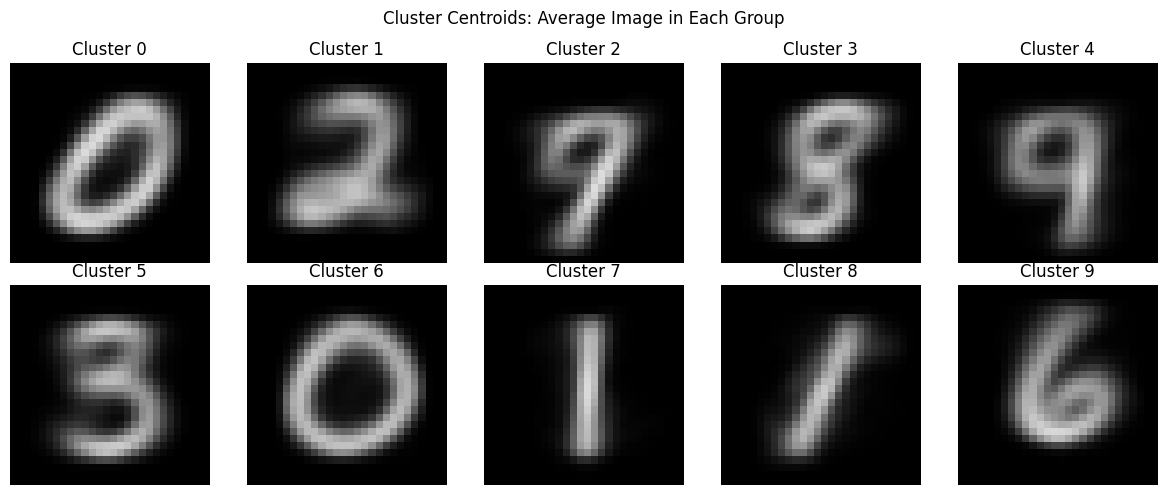

In [21]:
# Get the center of each cluster.
centroids = kmeans.cluster_centers_

# Create space for the 10 cluster centers.
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for cluster_id, ax in enumerate(axes.flat):
    # Turn the average pixel values into a 28 by 28 image.
    ax.imshow(
        centroids[cluster_id].reshape(28, 28),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    # Show the cluster number, not a digit label.
    ax.set_title(f"Cluster {cluster_id}")
    ax.axis("off")

plt.suptitle("Cluster Centroids: Average Image in Each Group")
plt.tight_layout()
plt.show()

Each centroid represents the average pixel values of all images in its cluster. Bright areas indicate where handwritten strokes commonly occur. The centroids appear blurred because images with different shapes, positions, and stroke thicknesses are averaged together.
Several centroids resemble recognizable digits. Clusters 0 and 6 resemble 0, Cluster 1 resembles 2, Cluster 5 resembles 3, and Cluster 9 resembles 6. Clusters 7 and 8 resemble upright and slanted versions of 1, respectively. Clusters 2 and 4 have patterns resembling 9, while Cluster 3 has a less distinct shape resembling a mixture of curved digits.
These appearances describe average shapes; they do not establish the actual digit composition of each cluster.

###Display five sample images from each cluster

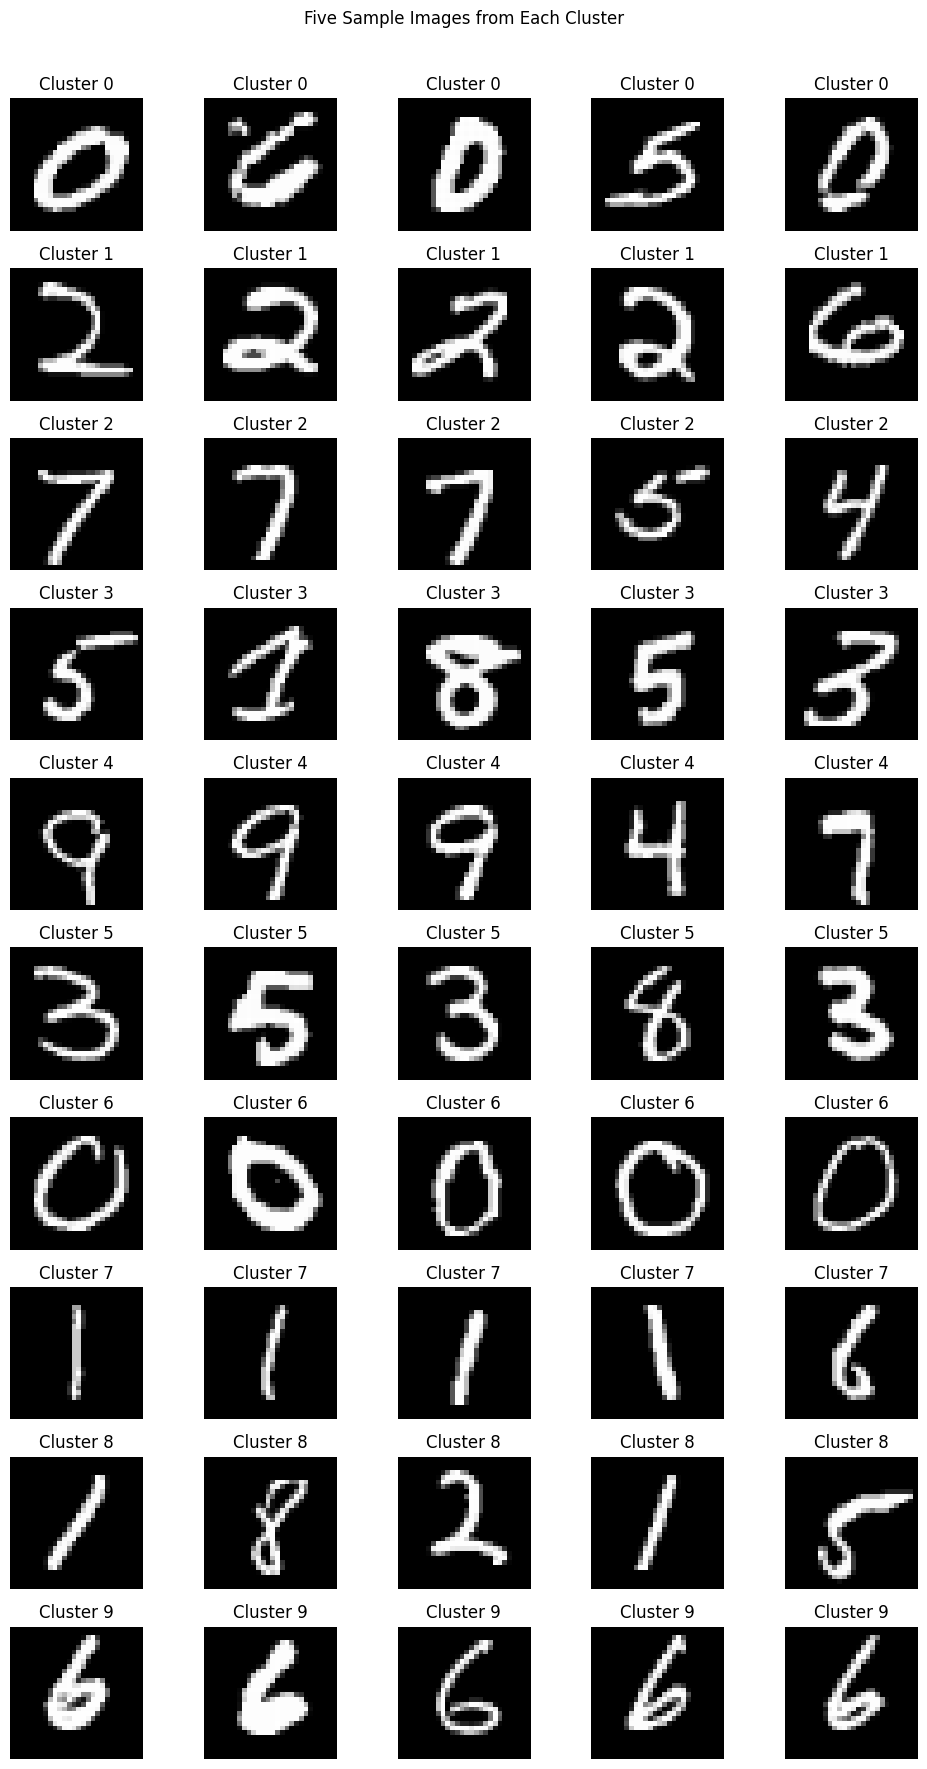

In [22]:
# Use a fixed seed to show the same examples when rerun.
example_rng = np.random.RandomState(42)

# Create one row per cluster and five images per row.
fig, axes = plt.subplots(10, 5, figsize=(10, 18))

for cluster_id in range(kmeans.n_clusters):
    # Find the sample images assigned to this cluster.
    member_indices = np.flatnonzero(clusters == cluster_id)

    # Choose five different images from this cluster.
    selected_indices = example_rng.choice(
        member_indices,
        size=5,
        replace=False
    )

    for column, image_index in enumerate(selected_indices):
        ax = axes[cluster_id, column]

        # Display the selected image.
        ax.imshow(
            X_sample[image_index].reshape(28, 28),
            cmap="gray",
            vmin=0,
            vmax=1
        )

        ax.set_title(f"Cluster {cluster_id}")
        ax.axis("off")

plt.suptitle("Five Sample Images from Each Cluster")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Each row shows five images assigned to the same cluster. Some rows show strong visual similarity. For example, all five displayed images in Cluster 6 appear to be 0, and all five in Cluster 9 appear to be 6. These groups are easier to interpret.
Other rows contain mixed digits. Cluster 4 shows images resembling 9, 4, and 7. Cluster 5 includes shapes resembling 3, 5, and 8. This suggests that K-Means sometimes groups different digits together when their pixel patterns share similar strokes or curves.
The same digit also appears across multiple clusters. For example, 0-like images occur in Clusters 0 and 6, while 1-like images occur in Clusters 7 and 8. The centroid differences suggest that writing angle and shape can influence these assignments.
Based on these examples, 4, 7, and 9, as well as 3, 5, and 8, appear difficult to separate consistently. However, five examples per cluster are only a small sample. Comparing all assignments with the actual labels in Part 4 will provide stronger evidence.

###1. Do images within the same cluster look similar?
Generally, yes. The sample images share features such as curves, loops, and stroke direction. For example, the displayed images in Cluster 6 look like zeros, while those in Cluster 9 look like sixes. However, some clusters contain visibly different digits.

###2. Does a cluster appear to contain mostly one digit?
Some clusters appear to. All five displayed examples in Cluster 6 resemble 0, and all five in Cluster 9 resemble 6. Other clusters, such as Clusters 3 and 5, appear more mixed. Since only five images were displayed per cluster, these observations do not confirm the composition of the whole cluster.

###3. Are some digits spread across multiple clusters?
Yes. I observed zero-like images in Clusters 0 and 6 and one-like images in Clusters 7 and 8. The centroids suggest that differences in handwriting style, such as upright versus slanted strokes, may cause the same digit to appear in separate groups.

###4. Which digits appear difficult for K-Means to separate?
Based on the plots, 4, 7, and 9, and 3, 5, and 8, appear difficult to separate. Examples resembling these digits occur together in mixed clusters. Their shared strokes and curves can produce similar pixel patterns, even when they represent different digits.

#Part 4 — Compare Clusters with the Actual Digit Labels

In [23]:
# Count how many examples of each digit appear in each cluster.
digit_counts = pd.crosstab(
    clusters,
    y_sample.astype(int)
)

# Print the digit counts for each cluster.
for cluster_id in digit_counts.index:
    counts = digit_counts.loc[cluster_id]
    total = counts.sum()

    # Find the most common digit in this cluster.
    most_common_digit = counts.idxmax()
    most_common_count = counts.max()
    percentage = most_common_count / total * 100

    print(f"\nCluster {cluster_id} — {total} images")

    # Show only digits that occur in this cluster.
    details = [
        f"Digit {digit}: {int(count)}"
        for digit, count in counts.items()
        if count > 0
    ]
    print(", ".join(details))

    print(
        f"Most common digit: {most_common_digit} "
        f"({percentage:.2f}% of this cluster)"
    )


Cluster 0 — 519 images
Digit 0: 427, Digit 2: 11, Digit 3: 17, Digit 5: 39, Digit 6: 14, Digit 7: 1, Digit 8: 7, Digit 9: 3
Most common digit: 0 (82.27% of this cluster)

Cluster 1 — 757 images
Digit 0: 5, Digit 1: 1, Digit 2: 666, Digit 3: 42, Digit 4: 8, Digit 5: 4, Digit 6: 10, Digit 7: 9, Digit 8: 12
Most common digit: 2 (87.98% of this cluster)

Cluster 2 — 1487 images
Digit 0: 4, Digit 1: 1, Digit 2: 8, Digit 3: 7, Digit 4: 290, Digit 5: 57, Digit 6: 1, Digit 7: 654, Digit 8: 23, Digit 9: 442
Most common digit: 7 (43.98% of this cluster)

Cluster 3 — 1039 images
Digit 0: 22, Digit 1: 2, Digit 2: 20, Digit 3: 146, Digit 4: 4, Digit 5: 266, Digit 6: 9, Digit 7: 1, Digit 8: 560, Digit 9: 9
Most common digit: 8 (53.90% of this cluster)

Cluster 4 — 1475 images
Digit 0: 3, Digit 1: 4, Digit 2: 26, Digit 3: 33, Digit 4: 500, Digit 5: 63, Digit 6: 14, Digit 7: 295, Digit 8: 34, Digit 9: 503
Most common digit: 9 (34.10% of this cluster)

Cluster 5 — 1331 images
Digit 0: 31, Digit 1: 5, 

###Interpretation
I compared the K-Means cluster assignments with the actual digit labels by counting how many examples of each digit appeared in each cluster. These labels were used only to interpret the results, not to train the model.
The output shows different levels of consistency across clusters. For example, Cluster 6 contains 458 zeros out of 513 images (89.28%), indicating a strong concentration of one digit. In contrast, Cluster 4 contains almost equal numbers of 9s (503) and 4s (500), along with 295 sevens, making it much more mixed.
The percentages describe the share of a cluster belonging to its most common digit; they are not classification accuracy scores. The results also clarify the earlier plots: although Cluster 2’s centroid resembled 9, its most common actual digit is 7 (43.98%). This shows why checking labels provides stronger evidence than interpreting a centroid alone.

### 1. Does each cluster mainly contain one digit?
No. Clusters 0, 1, 6, and 9 have strong majorities, with their most common digits accounting for approximately 82–89% of their images. Cluster 7 contains 70.86% ones. Clusters 3 and 5 have smaller majorities, while Clusters 2, 4, and 8 have no single digit representing more than half their images.

### 2. Which digits are grouped together?
Digits 4, 7, and 9 are frequently grouped together in Clusters 2 and 4. Digits 3, 5, and 8 commonly appear together in Clusters 3 and 5. These combinations suggest similarities in their handwritten pixel patterns.

### 3. Which digits appear in multiple clusters?
All ten digits appear in multiple clusters, although some have stronger concentrations in particular groups. Clear examples include 0 in Clusters 0 and 6, 1 in Clusters 7 and 8, and 4, 7, and 9 in Clusters 2 and 4. Digits 3, 5, and 8 are also distributed across Clusters 3 and 5, among others.

###4. Why might some digits be difficult to separate?
Different digits can share similar loops, curves, and straight strokes. Handwriting also varies in angle, thickness, and position. K-Means compares pixel values rather than understanding what a digit means, so it can group different digits with similar shapes together or split one digit across several clusters.

#Part 5 — Visualize the Clusters with PCA

In [24]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import numpy as np

In [25]:
#Apply PCA
# Reduce the 784 pixel features to two components.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

# Check the number of images and components.
print("Shape after PCA:", X_pca.shape)

Shape after PCA: (10000, 2)


In [26]:
#Check the explained variance
# Calculate the percentage of variation captured by each component.
variance_percent = pca.explained_variance_ratio_ * 100

print(f"PC1 explained variance: {variance_percent[0]:.2f}%")
print(f"PC2 explained variance: {variance_percent[1]:.2f}%")
print(f"Total explained variance: {variance_percent.sum():.2f}%")

PC1 explained variance: 9.82%
PC2 explained variance: 7.12%
Total explained variance: 16.94%


I applied PCA to reduce the 784 pixel features to two principal components. The resulting shape, (10000, 2), shows that all 10,000 sample images are still included, but each image now has two values for plotting.
The first principal component, PC1, captures 9.82% of the variation in the data, while PC2 captures 7.12%. Together, they represent 16.94% of the total variation. These percentages describe the variation retained, not prediction accuracy.

The remaining 83.06% of the variation is not represented in this two-dimensional view. Therefore, images or clusters that overlap in the plot may still differ in the original 784-feature space. PCA provides a simplified view; it does not change the existing K-Means assignments.

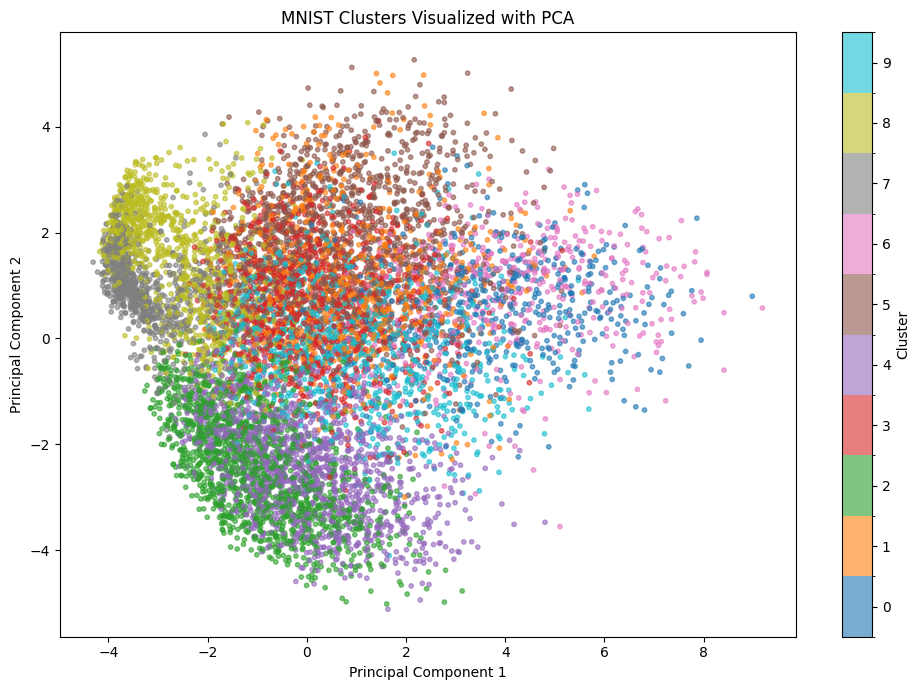

In [27]:
#Create the scatter plot
# Set a separate color for each cluster.
cmap = plt.get_cmap("tab10", kmeans.n_clusters)
boundaries = np.arange(-0.5, kmeans.n_clusters + 0.5, 1)
norm = BoundaryNorm(boundaries, cmap.N)

fig, ax = plt.subplots(figsize=(10, 7))

# Show each image as a point, colored by its existing cluster.
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap=cmap,
    norm=norm,
    s=10,
    alpha=0.6
)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("MNIST Clusters Visualized with PCA")

# Add a guide linking colors to cluster numbers.
colorbar = fig.colorbar(
    scatter,
    ax=ax,
    ticks=range(kmeans.n_clusters)
)
colorbar.set_label("Cluster")

plt.tight_layout()
plt.show()

I used PCA to reduce the 784 pixel features to two components and plotted all 10,000 images. Each point represents one image, and its color shows its K-Means cluster, not its actual digit label. The horizontal and vertical axes represent PC1 and PC2.

The plot shows some broad groupings, but substantial overlap remains. Clusters 7 and 8 form relatively distinct areas on the far left. Clusters 2 and 4 are concentrated toward the bottom, while Cluster 5 extends toward the top. Clusters 0 and 6 extend to the right but overlap considerably. Several colors mix heavily near the center.

PC1 and PC2 capture 16.94% of the total variation, so the plot presents only a limited view of the data. Overlap here does not necessarily mean that images are equally similar in the original 784-feature space.

###1. Do the clusters appear separated?
The clusters appear partially separated, but there are no clear gaps dividing all ten groups. Some occupy recognizable regions, while others mix substantially.

###2. Are some clusters overlapping?
Yes. Clusters 2 and 4 overlap in the lower region, and Clusters 0 and 6 overlap on the right. The center also contains many overlapping clusters.

###3. Which groups appear to be more clearly separated?
Clusters 7 and 8 are relatively more distinct on the far left, although their edges overlap with nearby groups. Cluster 5 also has a noticeable concentration in the upper region, but it is not fully isolated.

### 4. Does the PCA visualization support what you observed from the cluster images?
It broadly supports the earlier observations. Clusters 7 and 8 had centroids resembling different styles of 1 and occupy neighboring regions. Clusters 0 and 6, whose centroids resembled 0, overlap on the right. Clusters 2 and 4, which contained mixtures of 4, 7, and 9, also overlap. However, the limited explained variance means the plot cannot confirm every similarity seen in the images.

# Part 6 — Predict the Cluster of New Images

In [28]:
#Select ten unused images
# Find the original positions of all images.
all_indices = np.arange(len(X))

# Exclude every image used to train K-Means.
unused_indices = np.setdiff1d(all_indices, sample_indices)

# Choose ten unused images.
new_indices = unused_indices[:10]

X_new = X[new_indices]
y_new = y[new_indices]

print("Number of new images:", len(X_new))
print("New image positions:", new_indices)

# Confirm that none of these images were used for training.
overlap = np.intersect1d(new_indices, sample_indices)
print("Images shared with the training sample:", len(overlap))

Number of new images: 10
New image positions: [ 0  1  2  3  5  6  7  8  9 10]
Images shared with the training sample: 0


I selected ten images that were not included in the sample used to train K-Means. Their original dataset positions were 0, 1, 2, 3, 5, 6, 7, 8, 9, and 10. The output confirms zero images shared with the training sample, so these are unseen examples for the fitted model. They come from the same MNIST dataset, rather than a separate external dataset.

In [29]:
#Predict their clusters
# Assign each new image to the nearest learned cluster center.
new_clusters = kmeans.predict(X_new)

# Print the actual digit and assigned cluster for each image.
for position, actual_digit, cluster_id in zip(
    new_indices, y_new, new_clusters
):
    print(
        f"Image {position}: "
        f"Actual digit = {actual_digit}, "
        f"Assigned cluster = {cluster_id}"
    )

Image 0: Actual digit = 5, Assigned cluster = 3
Image 1: Actual digit = 0, Assigned cluster = 0
Image 2: Actual digit = 4, Assigned cluster = 4
Image 3: Actual digit = 1, Assigned cluster = 8
Image 5: Actual digit = 2, Assigned cluster = 1
Image 6: Actual digit = 1, Assigned cluster = 7
Image 7: Actual digit = 3, Assigned cluster = 3
Image 8: Actual digit = 1, Assigned cluster = 7
Image 9: Actual digit = 4, Assigned cluster = 2
Image 10: Actual digit = 3, Assigned cluster = 5


I used the trained model to assign each new image to its nearest cluster center without retraining. The digit 0 was assigned to Cluster 0, and the digit 2 to Cluster 1, consistent with the dominant digits previously found in those groups.
Some examples of the same digit received different assignments. The three images of 1 were assigned to Clusters 8, 7, and 7. The two images of 4 went to Clusters 4 and 2, while the two images of 3 went to Clusters 3 and 5. These results show that K-Means responds to differences in pixel patterns within the same digit.

The cluster numbers represent groups, not predicted digit labels. For example, assigning digit 5 to Cluster 3 does not mean the model predicted it as digit 3.

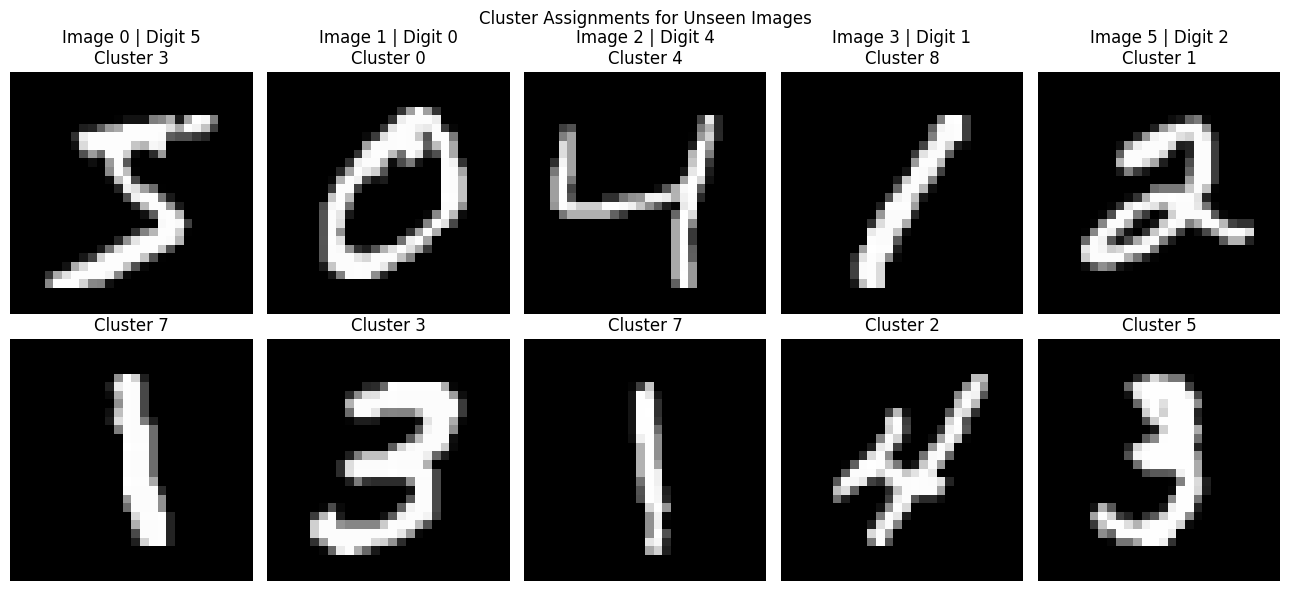

In [30]:
#Display the images and assignments
# Create space for ten images.
fig, axes = plt.subplots(2, 5, figsize=(13, 6))

for i, ax in enumerate(axes.flat):
    # Display the normalized image.
    ax.imshow(
        X_new[i].reshape(28, 28),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    # Show the actual digit separately from the cluster number.
    ax.set_title(
        f"Image {new_indices[i]} | Digit {y_new[i]}\n"
        f"Cluster {new_clusters[i]}"
    )
    ax.axis("off")

plt.suptitle("Cluster Assignments for Unseen Images")
plt.tight_layout()
plt.show()

I displayed the ten unseen images with their assigned clusters to compare their handwriting patterns visually. The slanted 1 in Image 3 was assigned to Cluster 8, while the more upright ones in Images 6 and 8 were assigned to Cluster 7. This agrees with the slanted and upright centroid patterns observed earlier.

The two examples of 4 also differ visibly: Image 2 has a wider, more upright shape, while Image 9 has a narrower, more slanted shape. They were assigned to different clusters. Likewise, the two examples of 3 differ in their curves and stroke thickness and received different assignments.

Images 0 and 7, showing 5 and 3, both entered Cluster 3. This is consistent with the earlier finding that this cluster contains a mixture of curved digits. Overall, the plot illustrates how handwriting style can influence assignments, although the model calculates distances using all 784 pixel features.


###1. Which cluster was assigned to each image?
- Image 0, digit 5 → Cluster 3
- Image 1, digit 0 → Cluster 0
- Image 2, digit 4 → Cluster 4
- Image 3, digit 1 → Cluster 8
- Image 5, digit 2 → Cluster 1
- Image 6, digit 1 → Cluster 7
- Image 7, digit 3 → Cluster 3
- Image 8, digit 1 → Cluster 7
- Image 9, digit 4 → Cluster 2
- Image 10, digit 3 → Cluster 5

###2. Do images that look similar receive similar cluster assignments?
Sometimes. The two upright examples of 1 were both assigned to Cluster 7, while the slanted 1 entered Cluster 8. However, the two examples of 4 and the two examples of 3 received different assignments. Similar digit identities do not always produce similar enough pixel patterns to enter the same cluster.

###3. Are any assignments surprising?
I initially found it surprising that Image 0, showing 5, and Image 7, showing 3, both entered Cluster 3. However, the earlier label comparison showed that this cluster contains both digits, along with many examples of 8. The assignment is therefore consistent with the cluster’s mixed composition.

###4. Why might K-Means sometimes assign an image to an unexpected cluster?
K-Means assigns an image to the nearest centroid using pixel distances, without understanding digit identities. Differences in slant, position, curves, and stroke thickness can make an image closer to a cluster containing other digits. A fixed number of clusters also means that different digit shapes may share a group.

#Part 7 — Final Analysis

###1. What did K-Means discover in the MNIST dataset?
K-Means discovered groups of images with similar pixel patterns without using digit labels. Some groups strongly corresponded to particular digits, while others contained several digits with similar shapes. It also separated different handwriting styles of the same digit into multiple clusters.

###2. What value of K did you choose, and why?
I chose K = 10 after comparing K = 5, 10, and 15. Inertia decreased by approximately 42,185 between K = 5 and 10, compared with 24,818 between K = 10 and 15. The smaller second improvement made K = 10 a reasonable choice, although testing only three values does not establish a definite optimum.

###3. What did the cluster centroids tell you?
The centroids showed the average handwriting pattern in each cluster. Several resembled recognizable digits, including 0, 1, 2, 3, and 6. Others were less distinct because they combined different shapes. For example, Clusters 7 and 8 resembled upright and slanted versions of 1, suggesting that writing style influenced the grouping.

###4. Did the clusters correspond closely to particular digits?
Some did. Digit 0 represented 89.28% of Cluster 6, digit 2 represented 87.98% of Cluster 1, and digit 6 represented 83.79% of Cluster 9. Other clusters were mixed. Cluster 4 contained nearly equal numbers of 9s and 4s, showing that a cluster does not necessarily represent one digit.

###5. Which digits were difficult to separate?
Digits 4, 7, and 9 frequently appeared together in Clusters 2 and 4. Digits 3, 5, and 8 also appeared together in Clusters 3 and 5. Their similar strokes, curves, and loops help explain why pixel-based clustering struggled to separate them.

###6. What did the PCA visualization show?
The PCA plot showed partial separation alongside substantial overlap. Clusters 7 and 8 occupied relatively distinct areas on the left, while several other groups overlapped near the center. The two components captured only 16.94% of the total variation, so the plot provides a limited view of the original data.

###7. What are some limitations of using K-Means for handwritten digit images?
K-Means compares pixel distances rather than understanding digit shapes. Changes in position, slant, and stroke thickness can therefore affect assignments. It also requires a chosen number of clusters and represents each group with one average center, which may not capture complex handwriting variation. As a result, different digits can share a cluster, and one digit can appear in several clusters.

###8. How is this project different from Project 3, where you used supervised learning?
In Project 3, the supervised model learned from data with known Buy, Sell, or Hold targets. In this project, I trained K-Means using only image pixels, without supplying the digit labels. The labels were used afterward to interpret the discovered groups rather than guide training.